In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
%%capture
!pip install yfinance
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

symbols = ["AAPL", "MSFT", "GOOGL", "AMZN", "NVDA"]

data = {}
for sym in symbols:
    data[sym] = yf.download( sym,
                            start="2018-01-01",
                            end="2025-01-01",
                            auto_adjust=True,
                            progress=False)
print(data["AAPL"].head())

In [4]:
for sym in symbols:
    df = data[sym].copy()
    df["returns"] = df["Close"].pct_change()
    data[sym] = df.dropna().copy()

In [5]:
for sym in symbols:
    df = data[sym].copy()
    df["target_eda_price_next"] = df["Close"].shift(-1)
    data[sym] = df.dropna().copy()


In [6]:
from sklearn.metrics import mean_absolute_error

for sym in symbols:
    df = data[sym].copy()
    mae = mean_absolute_error(df["target_eda_price_next"], df["Close"])
    print(f"{sym} baseline MAE:", round(mae, 3))

AAPL baseline MAE: 1.571
MSFT baseline MAE: 2.891
GOOGL baseline MAE: 1.372
AMZN baseline MAE: 1.961
NVDA baseline MAE: 0.69


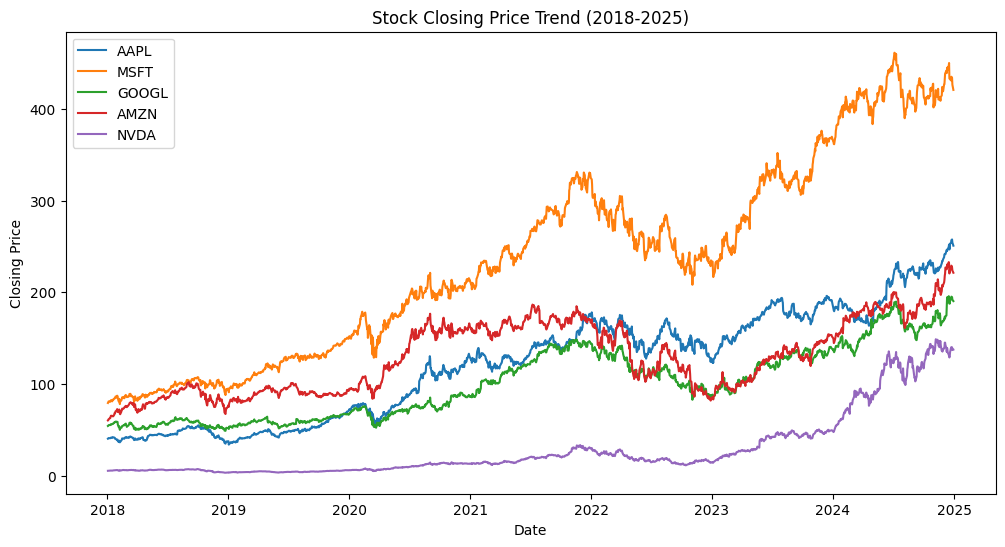

In [7]:
# Closing Price Trend (Time Series)

plt.figure(figsize=(12, 6))

for sym in symbols:
    plt.plot(data[sym].index, data[sym]["Close"], label=sym)

plt.title("Stock Closing Price Trend (2018-2025)")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.legend()
plt.show()

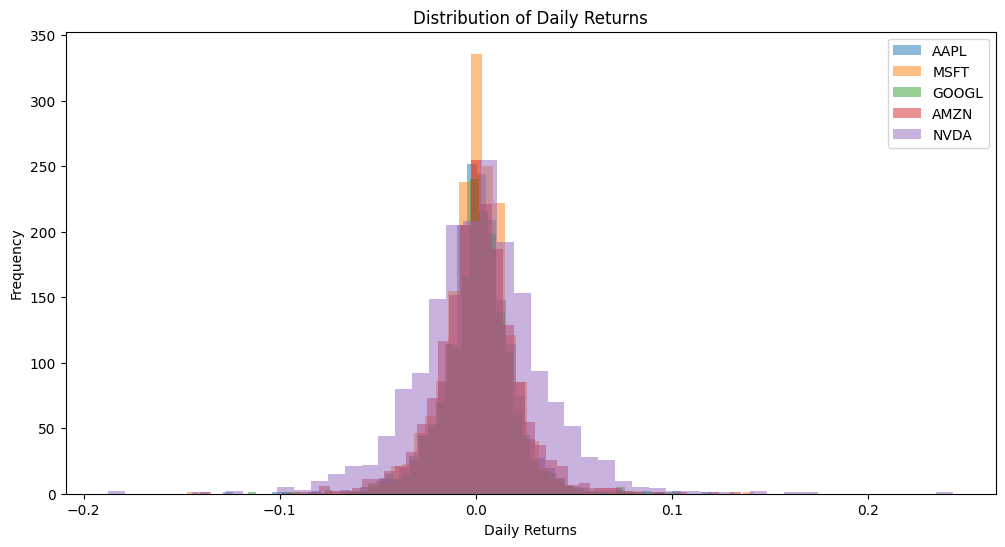

In [8]:
# Daily Returns Distribution (Risk Visualization)

plt.figure(figsize=(12, 6))

for sym in symbols:
    returns = data[sym]["returns"]
    plt.hist(returns.dropna(), bins=50, alpha=0.5, label=sym)

plt.title("Distribution of Daily Returns")
plt.xlabel("Daily Returns")
plt.ylabel("Frequency")
plt.legend()
plt.show()

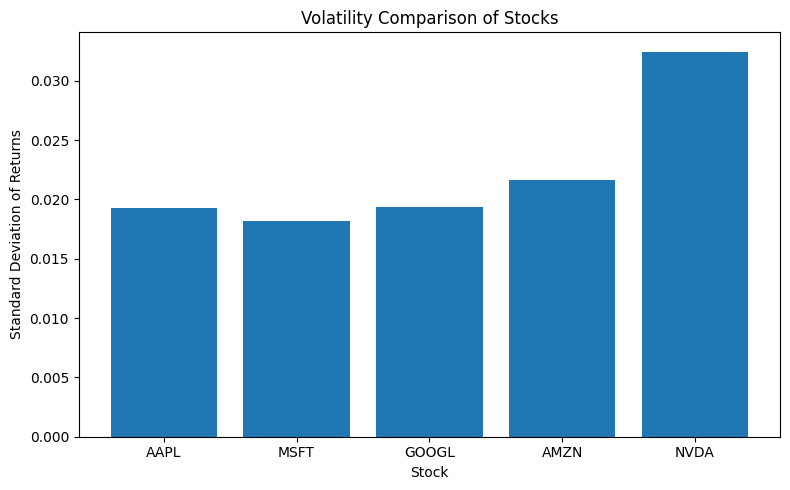

In [9]:
# Volatility Comparison (Bar Chart)

volatility = []

for sym in symbols:
    vol = data[sym]["returns"].std()
    volatility.append(vol)

vol_df = pd.DataFrame({
    "Stock": symbols,
    "Volatility": volatility
})

plt.figure(figsize=(8, 5))
plt.bar(vol_df["Stock"].values, vol_df["Volatility"].values)
plt.title("Volatility Comparison of Stocks")
plt.xlabel("Stock")
plt.ylabel("Standard Deviation of Returns")
plt.tight_layout()
plt.show()

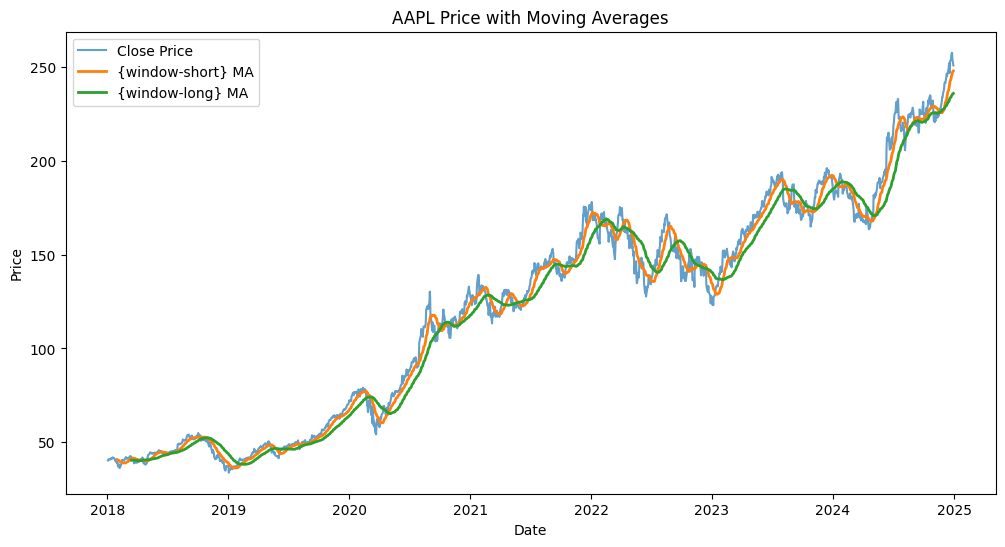

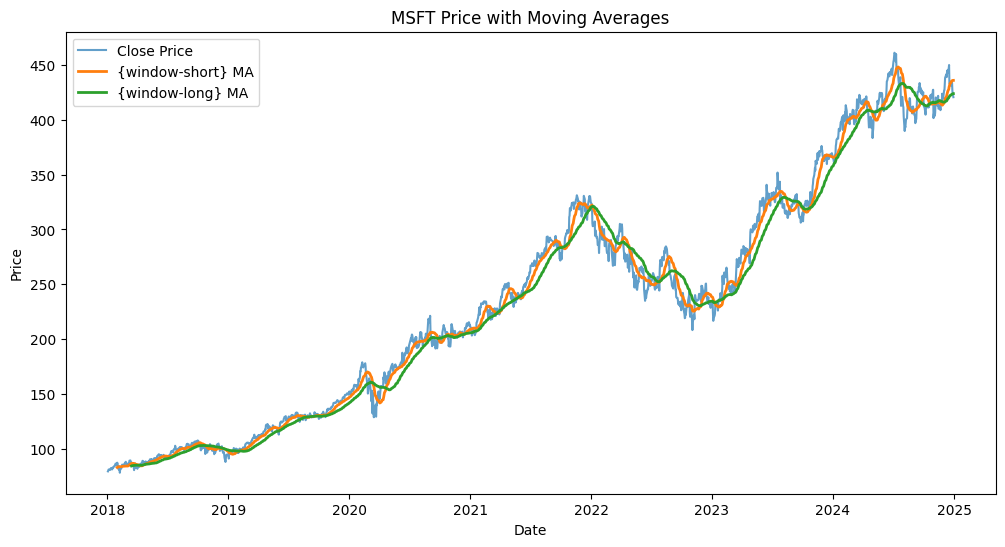

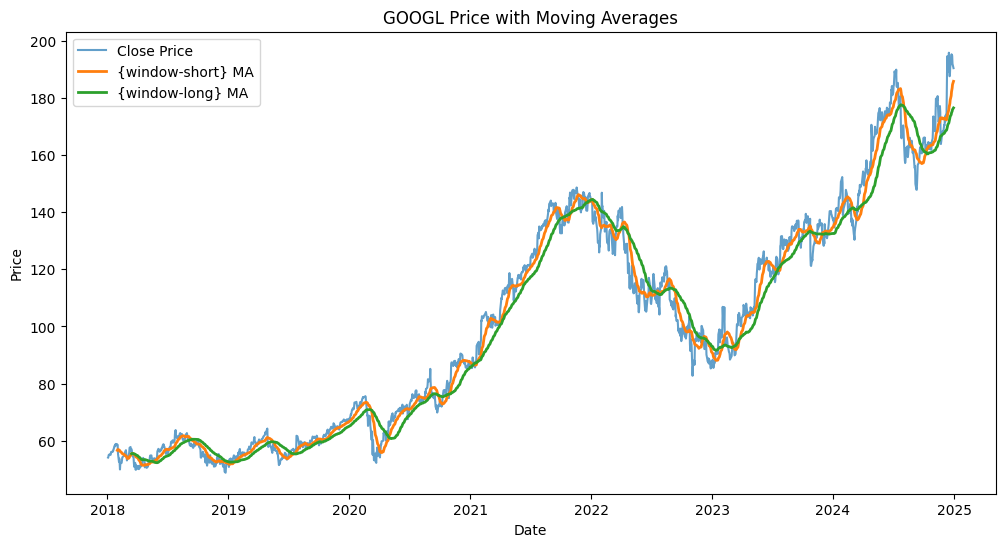

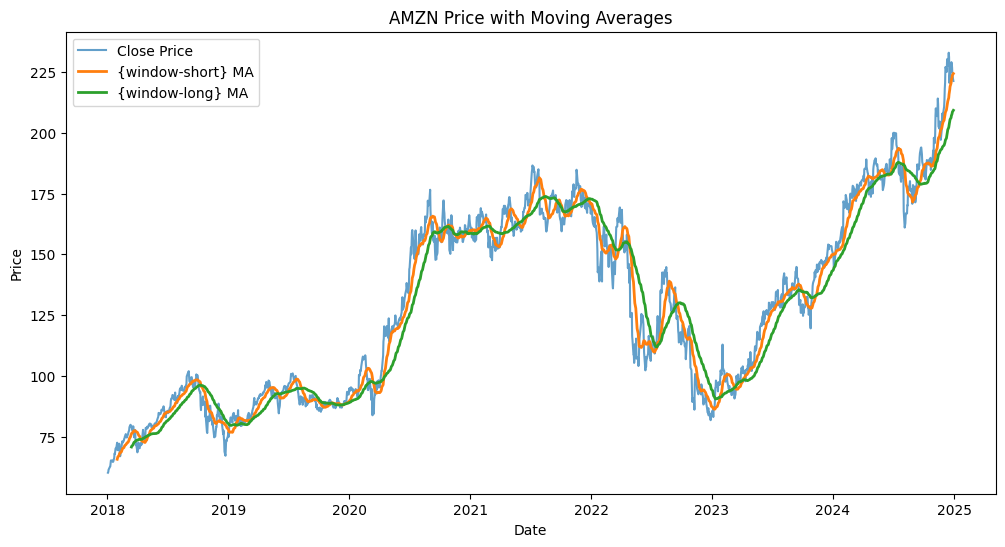

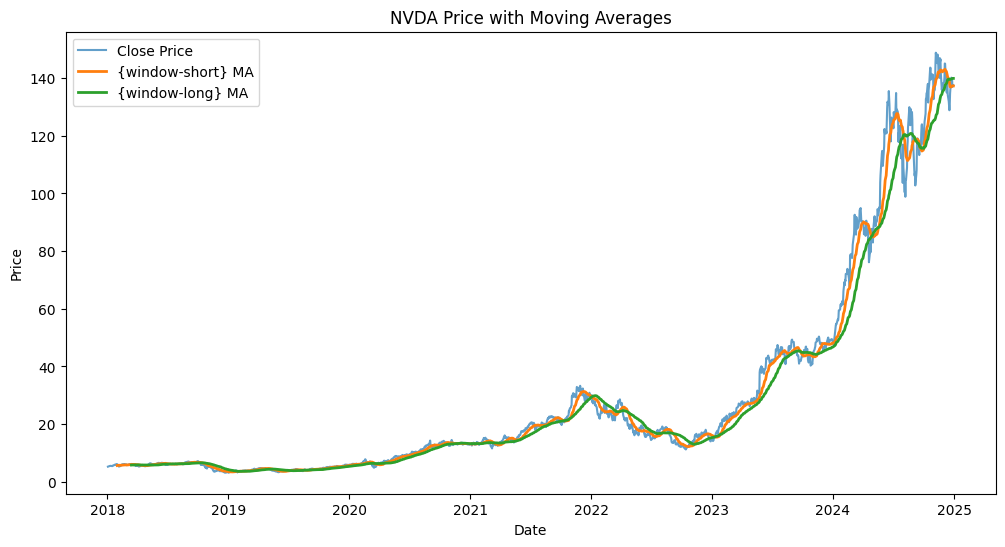

In [10]:
# Moving Averages (Trend Strength)

window_short = 20
window_long = 50

for sym in symbols:
    df = data[sym].copy()
    df["MA20"] = df["Close"].rolling(window_short).mean()
    df["MA50"] = df["Close"].rolling(window_long).mean()

    plt.figure(figsize=(12, 6))
    plt.plot(df.index, df["Close"], label="Close Price", alpha=0.7)
    plt.plot(df.index, df["MA20"], label="{window-short} MA", linewidth=2)
    plt.plot(df.index, df["MA50"], label="{window-long} MA", linewidth=2)
    plt.title(f"{sym} Price with Moving Averages")
    plt.xlabel("Date")
    plt.ylabel("Price")
    plt.legend()
    plt.show()

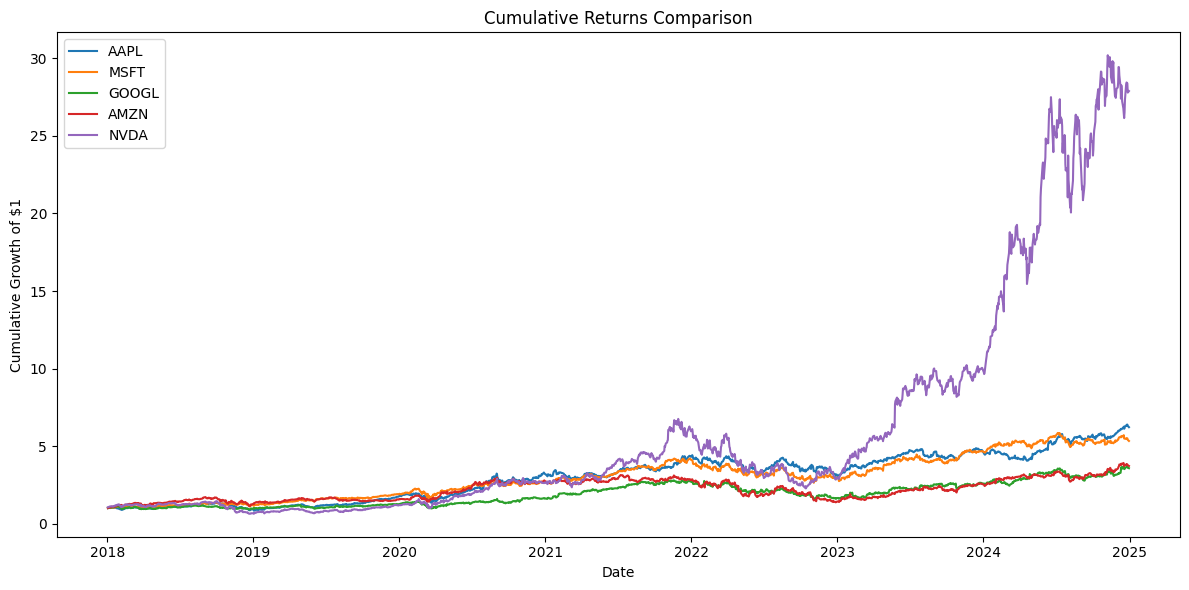

In [11]:
# Cumulative Returns (Performance Comparison)

plt.figure(figsize=(12, 6))

for sym in symbols:
    returns = data[sym]["returns"]
    cumulative_returns = (1 + returns).cumprod()
    plt.plot(cumulative_returns, label=sym)

plt.title("Cumulative Returns Comparison")
plt.xlabel("Date")
plt.ylabel("Cumulative Growth of $1")
plt.legend()
plt.tight_layout()
plt.show()

In [12]:
%%capture
!pip install tensorflow statsmodels
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import math

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from statsmodels.tsa.arima.model import ARIMA
from tensorflow.keras.optimizers import Adam

In [13]:
def create_sequences(series, window_size=60):
    series = np.asarray(series)
    X, y = [], []
    for i in range(len(series) - window_size):
        X.append(series[i:i+window_size])
        y.append(series[i+window_size])
    return np.array(X), np.array(y)

def evaluate(true, pred):
    true = np. asarray(true).reshape(-1)
    pred = np. asarray(pred).reshape(-1)
    mae = mean_absolute_error(true, pred)
    rmse = math.sqrt(mean_squared_error(true, pred))
    # mape = np.mean(np.abs((true - pred) / true)) * 100 removed mape due to potential division by zero issues
    return mae, rmse

In [14]:
window_size = 60

for sym in symbols:
    print(f"\n===== {sym} Deep Learning Models =====")

    df = data[sym].copy()
    prices = df["Close"].values.reshape(-1, 1)

    train_end = int(len(prices) * 0.7)
    val_end = int(len(prices) * 0.85)
    train_prices= prices[:train_end]
    val_prices = prices[train_end - window_size:val_end]
    test_prices = prices[val_end - window_size:]

    # Scale
    scaler = MinMaxScaler()
    train_scaled = scaler.fit_transform(train_prices)
    val_scaled = scaler.transform(val_prices)
    test_scaled = scaler.transform(test_prices)

    # Create sequences & split
    X_train, y_train = create_sequences(train_scaled, window_size)
    X_val, y_val = create_sequences(val_scaled, window_size)
    X_test, y_test = create_sequences(test_scaled, window_size)
    
    X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
    X_val = X_val.reshape((X_val.shape[0], X_val.shape[1], 1))
    X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    )
    # ---------------- LSTM ----------------
    lstm_model = Sequential([
        Input(shape=(window_size, 1)),
        LSTM(50),
        Dense(1)
    ])

    lstm_model.compile(optimizer="adam", loss="mse")
    lstm_model.fit(X_train, y_train,
                   validation_data=(X_val, y_val),
                   epochs=30, batch_size=32,
                    callbacks=[early_stop], verbose=0)

    lstm_pred_scaled = lstm_model.predict(X_test, verbose=0)
    lstm_pred = scaler.inverse_transform(lstm_pred_scaled)
    y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))

    lstm_mae, lstm_rmse = evaluate(y_test_actual, lstm_pred)

    print("LSTM Results:")
    print(f"MAE  : {lstm_mae:.3f}")
    print(f"RMSE : {lstm_rmse:.3f}")
    

    # ---------------- GRU ----------------
    gru_model = Sequential([
        Input(shape=(window_size, 1)),
        GRU(50),
        Dense(1) 
    ])

    gru_model.compile(optimizer="adam", loss="mse")
    gru_model.fit(X_train, y_train,
                   validation_data=(X_val, y_val),
                    epochs=30, batch_size=32,
                    callbacks=[early_stop], verbose=0)

    gru_pred_scaled = gru_model.predict(X_test, verbose=0)
    gru_pred = scaler.inverse_transform(gru_pred_scaled)

    gru_mae, gru_rmse = evaluate(y_test_actual, gru_pred)

    print("\nGRU Results:")
    print(f"MAE  : {gru_mae:.3f}")
    print(f"RMSE : {gru_rmse:.3f}")
    


===== AAPL Deep Learning Models =====
LSTM Results:
MAE  : 6.410
RMSE : 8.111

GRU Results:
MAE  : 3.635
RMSE : 4.576

===== MSFT Deep Learning Models =====
LSTM Results:
MAE  : 18.944
RMSE : 21.647

GRU Results:
MAE  : 6.673
RMSE : 7.834

===== GOOGL Deep Learning Models =====
LSTM Results:
MAE  : 3.715
RMSE : 4.690

GRU Results:
MAE  : 19.352
RMSE : 20.435

===== AMZN Deep Learning Models =====
LSTM Results:
MAE  : 3.358
RMSE : 4.449

GRU Results:
MAE  : 23.209
RMSE : 24.548

===== NVDA Deep Learning Models =====
LSTM Results:
MAE  : 38.265
RMSE : 43.438

GRU Results:
MAE  : 18.199
RMSE : 21.868


In [15]:
import warnings
from statsmodels.tools.sm_exceptions import ValueWarning, ConvergenceWarning

arima_orders = [(1, 1, 0), (2, 1, 0), (3, 1, 0), (5, 1, 0), (2, 1, 2)]

warnings.filterwarnings("ignore", category=ValueWarning)
warnings.filterwarnings("ignore", category=ConvergenceWarning)

for sym in symbols:
    print(f"\n===== {sym} ARIMA Model =====")

    df = data[sym].copy()
    df.index = pd.DatetimeIndex(df.index)
    df = df.asfreq("B")
    prices = df["Close"].dropna()

    train_end = int(len(prices) * 0.7)
    val_end = int(len(prices) * 0.85)

    train = prices.iloc[:train_end]
    val = prices.iloc[train_end:val_end]
    test = prices.iloc[val_end:]

    best_order = None
    best_val_rmse = float("inf")

    for order in arima_orders:
        try:
            model = ARIMA(train, order=order)
            fitted = model.fit()
            val_forecast = fitted.forecast(steps=len(val))
            _, val_rmse = evaluate(val.values, val_forecast.values)

            if val_rmse < best_val_rmse:
                best_val_rmse = val_rmse
                best_order = order
        except Exception:
            continue

    print(f"Best validation order: ARIMA{best_order}")
    print(f"Validation RMSE    : {best_val_rmse:.3f}")

    train_val = prices.iloc[:val_end]
    final_model = ARIMA(train_val, order=best_order)
    final_fitted = final_model.fit()

    test_forecast = final_fitted.forecast(steps=len(test))
    test_mae, test_rmse = evaluate(test.values, test_forecast.values)

    print("Final Test Results:")
    print(f"MAE  : {test_mae:.3f}")
    print(f"RMSE : {test_rmse:.3f}")


===== AAPL ARIMA Model =====
Best validation order: ARIMA(2, 1, 2)
Validation RMSE    : 27.305
Final Test Results:
MAE  : 23.748
RMSE : 28.391

===== MSFT ARIMA Model =====
Best validation order: ARIMA(5, 1, 0)
Validation RMSE    : 74.782
Final Test Results:
MAE  : 47.209
RMSE : 51.308

===== GOOGL ARIMA Model =====
Best validation order: ARIMA(5, 1, 0)
Validation RMSE    : 25.509
Final Test Results:
MAE  : 29.233
RMSE : 33.293

===== AMZN ARIMA Model =====
Best validation order: ARIMA(3, 1, 0)
Validation RMSE    : 30.814
Final Test Results:
MAE  : 37.026
RMSE : 41.284

===== NVDA ARIMA Model =====
Best validation order: ARIMA(2, 1, 2)
Validation RMSE    : 21.911
Final Test Results:
MAE  : 58.170
RMSE : 65.064


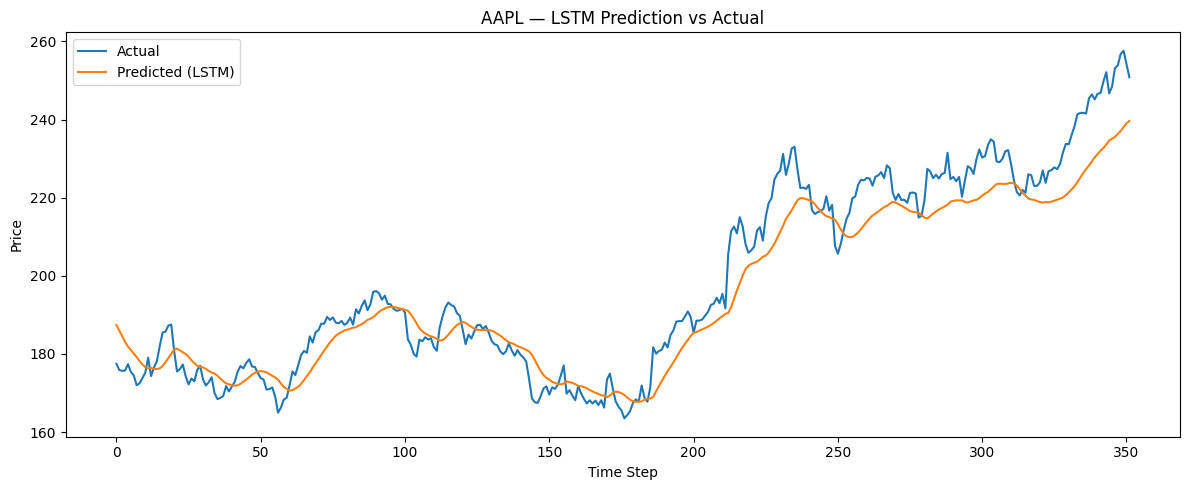

In [16]:
sym = "AAPL"
window_size = 60

df = data[sym].copy()
prices = df["Close"].values.reshape(-1, 1)

split_index = int(len(prices) * 0.8)
train_prices = prices[:split_index]
test_prices = prices[split_index - window_size:]

scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train_prices)
test_scaled = scaler.transform(test_prices)

X_train, y_train = create_sequences(train_scaled, window_size)
X_test, y_test = create_sequences(test_scaled, window_size)

X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

model = Sequential([
    Input(shape=(window_size, 1)),
    LSTM(50),
    Dense(1)
])

model.compile(optimizer="adam", loss="mse")
model.fit(X_train, y_train, epochs=5, batch_size=32, verbose=0)

pred_scaled = model.predict(X_test, verbose=0)
pred = scaler.inverse_transform(pred_scaled)
actual = scaler.inverse_transform(y_test.reshape(-1, 1))

plt.figure(figsize=(12, 5))
plt.plot(actual, label="Actual")
plt.plot(pred, label="Predicted (LSTM)")
plt.title("AAPL — LSTM Prediction vs Actual")
plt.xlabel("Time Step")
plt.ylabel("Price")
plt.legend()
plt.tight_layout()
plt.show()

In [17]:
df = data[sym].copy()

df.loc[:, "log_return"] = np.log(df["Close"] / df["Close"].shift(1))
df.loc[:, "target"] = df["log_return"].shift(-1)

df.loc[:, "volatility_14"] = df["log_return"].rolling(window=14).std()
df.loc[:, "volatility_30"] = df["log_return"].rolling(window=30).std()
df.loc[:, "momentum_10"] = df["Close"] - df["Close"].shift(10)
df.loc[:, "momentum_20"] = df["Close"] - df["Close"].shift(20)
df.loc[:, "ema_10"] = df["Close"].ewm(span=10, adjust=False).mean()
df.loc[:, "volume_change"] = df["Volume"].pct_change()

df = df.dropna().copy()

features = [
    "log_return",
    "volatility_14",
    "momentum_10",
    "ema_10",
    "volume_change",
]

missing_cols = [col for col in features + ["target"] if col not in df.columns]
if missing_cols:
    raise ValueError(f"Missing columns after feature engineering: {missing_cols}")

X = df.loc[:, features].copy()
y = df.loc[:, "target"].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)
print(df[features + ["target"]].head())

X shape: (1728, 5)
y shape: (1728,)
Price      log_return volatility_14 momentum_10     ema_10 volume_change  \
Ticker                                                                     
Date                                                                       
2018-02-15   0.033027      0.026653    1.384029  38.724577      0.258392   
2018-02-16  -0.003243      0.025949    2.955780  39.048916     -0.214501   
2018-02-20  -0.003369      0.025897    3.757767  39.289510     -0.155456   
2018-02-21  -0.004549      0.025962    2.044323  39.453041      0.104363   
2018-02-22   0.008324      0.026020    3.196842  39.647921     -0.172923   

Price         target  
Ticker                
Date                  
2018-02-15 -0.003243  
2018-02-16 -0.003369  
2018-02-20 -0.004549  
2018-02-21  0.008324  
2018-02-22  0.017242  


In [18]:


train_end = int(len(X) * 0.7)
val_end = int(len(X) * 0.85)

X_train = X.iloc[:train_end].copy()
X_val = X.iloc[train_end:val_end].copy()
X_test = X.iloc[val_end:].copy()

y_train = y.iloc[:train_end].copy()
y_val = y.iloc[train_end:val_end].copy()
y_test = y.iloc[val_end:].copy()

scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_val_scaled = scaler_X.transform(X_val)
X_test_scaled = scaler_X.transform(X_test)

y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1))
y_val_scaled = scaler_y.transform(y_val.values.reshape(-1, 1))
y_test_scaled = scaler_y.transform(y_test.values.reshape(-1, 1))

In [19]:
# Cell 52: Create rolling sequences
def create_sequences(X, y, dates, lookback=30):
    X_seq, y_seq, date_seq = [], [], []
    for i in range(lookback, len(X)):
        X_seq.append(X[i-lookback:i])
        y_seq.append(y[i])
        date_seq.append(dates[i])
    return np.array(X_seq), np.array(y_seq), np.array(date_seq)

dates = df.index

lookback = 30
Xseq, yseq, dateseq = create_sequences(X, y, dates, lookback=lookback)

print(Xseq.shape, yseq.shape, dateseq.shape)

(1698, 30, 5) (1698,) (1698,)


In [20]:
def split_data_three_way(X, y, dates, train_ratio=0.7, val_ratio=0.15):
    n = len(X)
    train_end = int(n * train_ratio)
    val_end = int(n * (train_ratio + val_ratio))

    X_train = X[:train_end]
    X_val = X[train_end:val_end]
    X_test = X[val_end:]

    y_train = y[:train_end]
    y_val = y[train_end:val_end]
    y_test = y[val_end:]

    dates_train = dates[:train_end]
    dates_val = dates[train_end:val_end]
    dates_test = dates[val_end:]

    return X_train, X_val, X_test, y_train, y_val, y_test, dates_train, dates_val, dates_test

X_train, X_val, X_test, y_train, y_val, y_test, dates_train, dates_val, dates_test = split_data_three_way(
    Xseq, yseq, dateseq, train_ratio=0.7, val_ratio=0.15
)

print("Train:", X_train.shape, y_train.shape)
print("Val:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (1188, 30, 5) (1188,)
Val: (255, 30, 5) (255,)
Test: (255, 30, 5) (255,)


In [21]:
def build_lstm(input_shape):
    model = Sequential([
        Input(shape=input_shape),

        LSTM(64, return_sequences=True),
        Dropout(0.3),

        LSTM(64),
        Dropout(0.3),

        Dense(1)
    ])

    model.compile(optimizer=Adam(learning_rate=0.001), loss="mse")
    return model

In [22]:
input_shape = (X_train.shape[1], X_train.shape[2])
model = build_lstm(input_shape)

history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_val, y_val),
    verbose=1
)

Epoch 1/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - loss: 0.0211 - val_loss: 5.0069e-04
Epoch 2/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0065 - val_loss: 3.7722e-04
Epoch 3/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0036 - val_loss: 5.6163e-04
Epoch 4/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0024 - val_loss: 1.9029e-04
Epoch 5/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0021 - val_loss: 3.6090e-04
Epoch 6/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0017 - val_loss: 2.4101e-04
Epoch 7/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0015 - val_loss: 2.4156e-04
Epoch 8/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0013 - val_loss: 1.7450e-04
Epoch 9/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0011 - val_loss: 1.8138e-04
Epoch 10/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0010 - val_loss: 1.7430e-04
Epoch 11/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 9.8608e-04 - val_loss: 1.7277e-04
Epoch 12/50
38/

In [23]:
def build_gru(input_shape):
    model = Sequential([
        Input(shape=input_shape),

        GRU(64, return_sequences=True),
        Dropout(0.3),

        GRU(64),
        Dropout(0.3),

        Dense(1)
    ])

    model.compile(optimizer=Adam(learning_rate=0.001), loss="mse")
    return model

In [24]:
y_pred_scaled = model.predict(X_test, verbose=0)
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_true = scaler_y.inverse_transform(y_test.reshape(-1, 1))

last_train_price = df["Close"].iloc[len(X_train) + lookback - 1]

predicted_prices = []
price = last_train_price

for r in y_pred.flatten():
    price = price * np.exp(r)
    predicted_prices.append(price)

In [25]:
series = df["log_return"].dropna().copy()

train_size = int(len(series) * 0.8)
train = series.iloc[:train_size]
test = series.iloc[train_size:]

arima_model = ARIMA(train, order=(5, 0, 2))
arima_fit = arima_model.fit()

forecast = arima_fit.forecast(steps=len(test))

In [26]:
hybrid_model = Sequential([
    Input(shape=(X_train.shape[1], X_train.shape[2])),
    LSTM(64, return_sequences=True),
    Dropout(0.2),
    GRU(32),
    Dropout(0.2),
    Dense(1)
])

hybrid_model.compile(optimizer="adam", loss="mse")
hybrid_model.summary()

Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_8 (LSTM)                   │ (None, 30, 64)         │        17,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_5 (GRU)                     │ (None, 32)             │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27,361 (106.88 KB)

 Trainable params: 27,361 (106.88 KB)

 Non-trainable params: 0 (0.00 B)

In [27]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "best_model.keras",
    monitor="val_loss",
    save_best_only=True
)

history = hybrid_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop, checkpoint],
    verbose=1
)

Epoch 1/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 0.1606 - val_loss: 8.1428e-04
Epoch 2/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0515 - val_loss: 0.0025
Epoch 3/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0207 - val_loss: 5.7523e-04
Epoch 4/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0126 - val_loss: 6.6844e-04
Epoch 5/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0103 - val_loss: 4.0678e-04
Epoch 6/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0087 - val_loss: 3.0633e-04
Epoch 7/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0063 - val_loss: 4.8456e-04
Epoch 8/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0060 - val_loss: 2.5425e-04
Epoch 9/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0055 - val_loss: 2.2855e-04
Epoch 10/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0051 - val_loss: 0.0018
Epoch 11/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0043 - val_loss: 2.7162e-04
Epoch 12/50
38/38 ━━━━━━━━━

In [28]:
batch_sizes = [16, 32]
epochs_list = [20, 40]

for batch in batch_sizes:
    for ep in epochs_list:
        print(f"Training with batch={batch}, epochs={ep}")

        temp_model = Sequential([
            Input(shape=(X_train.shape[1], X_train.shape[2])),
            LSTM(64, return_sequences=True),
            Dropout(0.2),
            GRU(32),
            Dropout(0.2),
            Dense(1)
        ])

        temp_model.compile(optimizer="adam", loss="mse")

        temp_model.fit(
            X_train, y_train,
            validation_data=(X_val, y_val),
            epochs=ep,
            batch_size=batch,
            verbose=0
        )

Training with batch=16, epochs=20
Training with batch=16, epochs=40
Training with batch=32, epochs=20
Training with batch=32, epochs=40


X_test shape: (255, 30, 5)
Predictions shape: (255,)
Actuals shape: (255,)
First 5 predictions: [-0.13846442 -0.13845135 -0.13840388 -0.13851228 -0.1384952 ]
First 5 actuals: [-0.13842151 -0.13757789 -0.13714995 -0.13907226 -0.14685005]


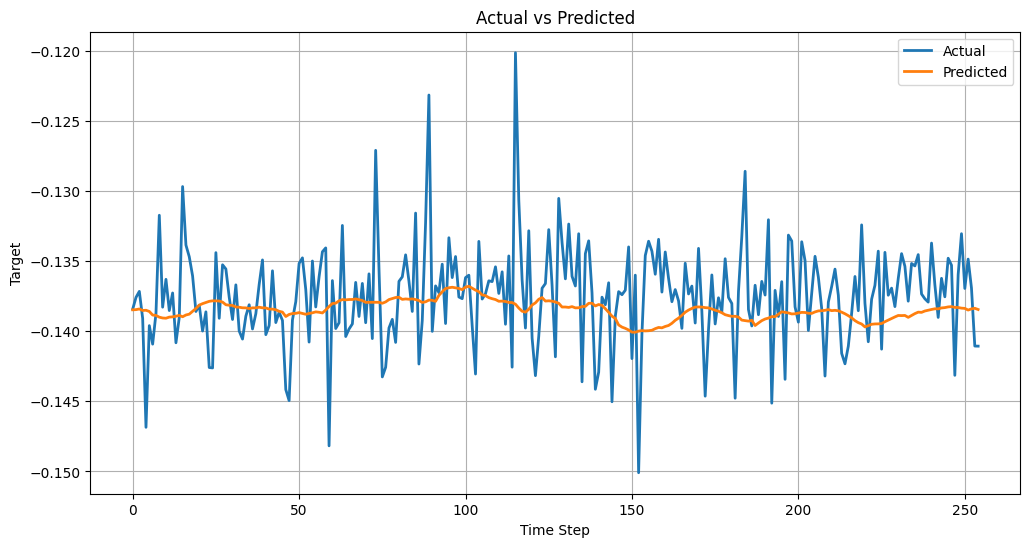

In [29]:
# 1) Predict on the prepared test sequences
pred_scaled = hybrid_model.predict(X_test, verbose=0)

# 2) Make sure arrays are 2D for inverse_transform
pred_scaled = np.array(pred_scaled).reshape(-1, 1)
y_test_2d = np.array(y_test).reshape(-1, 1)

# 3) Inverse transform if you used a target scaler
# Replace scaler_y with your actual target scaler variable name if different
predictions = scaler_y.inverse_transform(pred_scaled).flatten()
actuals = scaler_y.inverse_transform(y_test_2d).flatten()

# 4) Quick checks
print("X_test shape:", X_test.shape)
print("Predictions shape:", predictions.shape)
print("Actuals shape:", actuals.shape)
print("First 5 predictions:", predictions[:5])
print("First 5 actuals:", actuals[:5])

# 5) Plot actual vs predicted
plt.figure(figsize=(12, 6))
plt.plot(actuals, label="Actual", linewidth=2)
plt.plot(predictions, label="Predicted", linewidth=2)
plt.title("Actual vs Predicted")
plt.xlabel("Time Step")
plt.ylabel("Target")
plt.legend()
plt.grid(True)
plt.show()